
<b>Imports</b>

In [1]:
import tensorflow as tf

from sklearn.model_selection import train_test_split
from sklearn.utils import shuffle

import numpy as np
import os
from glob import glob
from PIL import Image
import sys

project_root = os.path.abspath(os.path.join(".."))  # One level up from current script
if project_root not in sys.path:
    sys.path.append(project_root)
    
from src.utils import preprocess_caption_annotation, preprocess_captionning_image, load_caption_dataset, create_caption_dataset, captionning_evaluate, plot_attention
from src.model_loader import ModelLoader

2025-04-24 12:03:13.360919: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1745488993.389837   33053 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1745488993.397694   33053 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1745488993.429772   33053 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1745488993.429809   33053 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1745488993.429811   33053 computation_placer.cc:177] computation placer alr

# Chargement des images

In [2]:

annotation_file="../../annotations/captions_train2014.json"
image_folder = "../../train2014/"

train_captions, img_name_vector = load_caption_dataset(annotation_file, image_folder, nb_images=6000)

6000 images sélectionnées.
Total de 30015 légendes pour 6000 images.


30015 30015
<start> A very clean and well decorated empty bathroom <end>


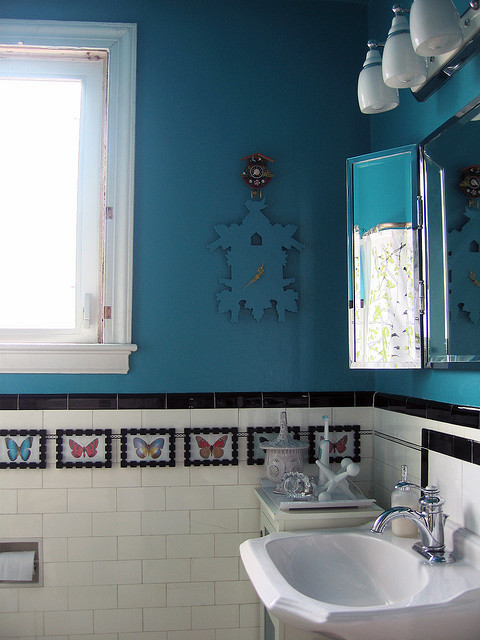

In [3]:
print(len(train_captions), len(img_name_vector))
print(train_captions[0])
Image.open(img_name_vector[0])

In [3]:
image_features_extract_model = preprocess_captionning_image(img_name_vector)

I0000 00:00:1745489003.758119   33053 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 5564 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3070 Ti Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.6
100%|██████████| 375/375 [01:49<00:00,  3.44it/s]


**Pré-traitement des annotations** (Pour l'entrainement)

In [4]:
tokenizer = None
cap_vector = None
max_length = 0

In [ ]:
nb_top_words = 5000

cap_vector, tokenizer, max_length = preprocess_caption_annotation(train_captions, is_training=True,nb_top_word=nb_top_words)

Création du Tokenizer et du vecteur d'annotations terminée.
Taille du vocabulaire :  3130
Taille maximale des annotations :  32


**Pré-traitement des annotations** Sans entrainement

In [4]:
tokenizer_reload_path = "./../models/weights/captioning_token/captioning_tokenizer_GRU.json"


tokenizer, nb_top_words, max_length = preprocess_caption_annotation(train_captions, is_training=False, tokenizer_path=tokenizer_reload_path)

Chargement du Tokenizer terminé.
Taille du vocabulaire :  6816
Taille maximale des annotations :  5000


In [5]:
vocab_size = nb_top_words + 1

# 1 Formation du jeu d'entrainement et de test :


In [6]:
train_dataset, img_name_train, cap_train, val_dataset, img_name_val, cap_val, num_steps, val_num_steps = create_caption_dataset(train_captions,img_name_vector, tokenizer)

Train Dataset size: 24012
Validation Dataset size: 6003


In [8]:
GRU_Captionning_model = ModelLoader(model_name="GRU_Captionning")

encoder, decoder = GRU_Captionning_model.create_captionning_autoencoder(vocab_size=vocab_size, is_gru=True, init_weigths_path_encoder="../models/weights/caption/encoder_captioning_excellent.weights.h5", init_weigths_path_decoder="../models/weights/caption/decoder_captioning_excellent.weights.h5")

✅ Model crée avec succès
✅ Poids restaurés depuis les fichiers .h5


/home/fares/datascience/.venv/lib/python3.12/site-packages/keras/src/layers/layer.py:396: UserWarning: `build()` was called on layer 'cnn__encoder_1', however the layer does not have a `build()` method implemented and it looks like it has unbuilt state. This will cause the layer to be marked as built, despite not being actually built, which may cause failures down the line. Make sure to implement a proper `build()` method.
  warnings.warn(
/home/fares/datascience/.venv/lib/python3.12/site-packages/keras/src/layers/layer.py:396: UserWarning: `build()` was called on layer 'rnn__decoder_1', however the layer does not have a `build()` method implemented and it looks like it has unbuilt state. This will cause the layer to be marked as built, despite not being actually built, which may cause failures down the line. Make sure to implement a proper `build()` method.
  warnings.warn(


In [10]:
LSTM_Captionning_model = ModelLoader(model_name="LSTM_Captionning")

encoder2, decoder2 = GRU_Captionning_model.create_captionning_autoencoder(vocab_size=vocab_size, is_gru=False)

✅ Model crée avec succès


In [12]:

# La fonction de perte
loss_object = tf.keras.losses.SparseCategoricalCrossentropy(
    from_logits=True, reduction='none')

def loss_function(real, pred):
    mask = tf.math.logical_not(tf.math.equal(real, 0))
    loss_ = loss_object(real, pred)

    mask = tf.cast(mask, dtype=loss_.dtype)
    loss_ *= mask

    return tf.reduce_mean(loss_)

Pour garder la trace de votre apprentissage et la sauvegarder, vous pouvez utiliser la classe [`tf.train.Checkpoint`](https://www.tensorflow.org/api_docs/python/tf/train/Checkpoint).

Initialisation de l'époque de début d’entrainement dans `start_epoch`. La classe `tf.train.Checkpoint` permet de poursuivre l’entrainement là ou vous l’avez laissé s’il avait été interrompu auparavant.

# 3.2 Test

Caption token ids: <start> A statue of a bunny face on a woman's body on a bicycle.  <end>
Index word sample: [(1, '<unk>'), (2, 'a'), (3, '<start>'), (4, '<end>'), (5, 'with'), (6, 'and'), (7, 'in'), (8, 'the'), (9, 'of'), (10, 'on')]
Real Caption: 
Prediction Caption: dream snowboarding snowboarding snowboarding snowboarding snowboarding perch perch perch perch perch perch perch perch perch perch perch perch perch perch perch perch perch perch perch perch perch perch perch perch perch perch perch perch perch perch perch perch perch perch perch perch perch perch perch perch perch


/home/fares/datascience/Leyenda/src/utils.py:599: UserWarning: Glyph 128302 (\N{CRYSTAL BALL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/home/fares/datascience/Leyenda/src/utils.py:599: UserWarning: Glyph 128444 (\N{FRAME WITH PICTURE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/home/fares/datascience/Leyenda/src/utils.py:599: UserWarning: Tight layout not applied. tight_layout cannot make Axes height small enough to accommodate all Axes decorations.
  plt.tight_layout()
/home/fares/datascience/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128302 (\N{CRYSTAL BALL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/fares/datascience/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128444 (\N{FRAME WITH PICTURE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


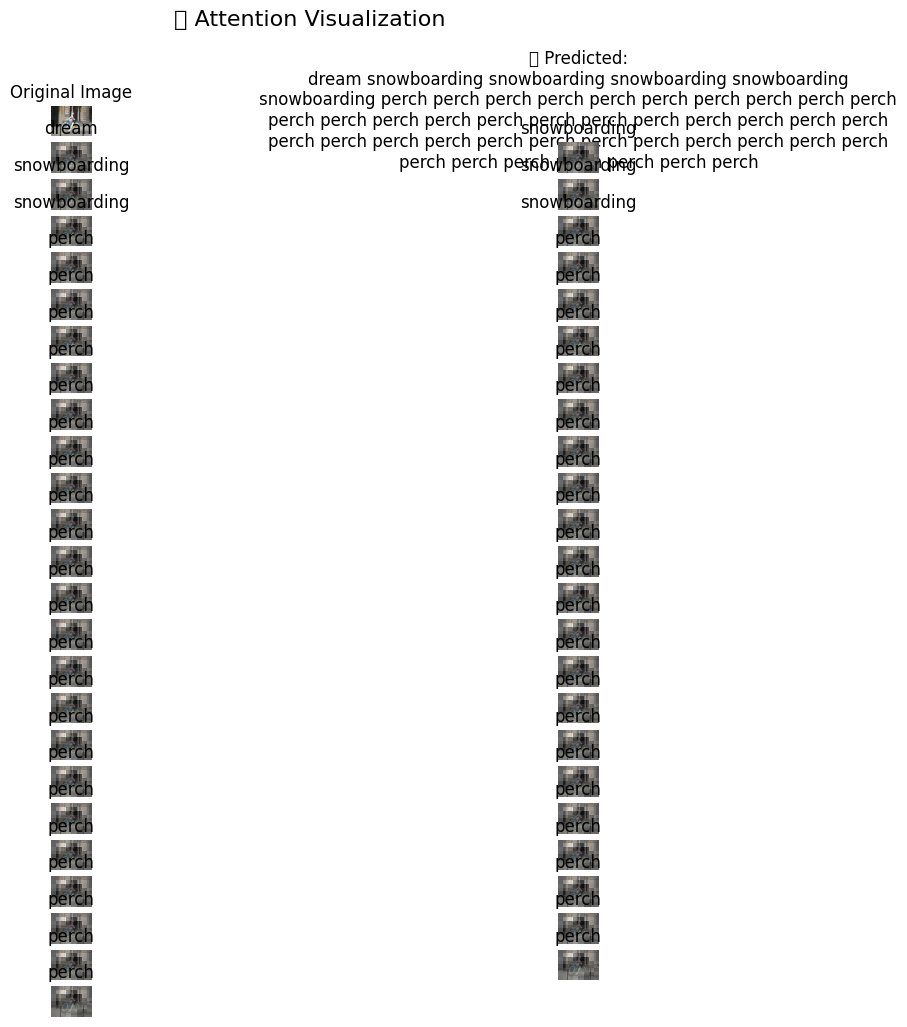

In [ ]:
# Affichage de quelques annotations dans le jeu de test
rid = np.random.randint(0, len(img_name_val))
image = img_name_val[rid]
print("Caption token ids:", cap_val[rid])
print("Index word sample:", list(tokenizer.index_word.items())[:10])
real_caption = ' '.join([
    tokenizer.index_word[i] for i in cap_val[rid]
    if i not in [0] and i in tokenizer.index_word
])
result, attention_plot, bleu_score = captionning_evaluate(image, encoder, decoder, real_caption, max_length, image_features_extract_model, tokenizer, is_gru=False)

print ('Real Caption:', real_caption)
print ('Prediction Caption:', ' '.join(result))
plot_attention(image, result, attention_plot, real_caption=real_caption)